In [10]:
!rm -rf /content/runs

In [1]:
pip install ultralytics ultralytics

In [2]:
pip install ultralytics roboflow

In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="secret")
project = rf.workspace("university-of-toronto-xho85").project("numberdetection-eppfj")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="secret")
project = rf.workspace("soumyadeep-dutta").project("yolov5-svhn")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt").to("cuda")
model.train(
    data="numberdetection-2/data.yaml",
    epochs=10,
    batch=16,
    imgsz=768,
    workers=2,
    patience=3,
    lr0=0.001,
)
model = YOLO("runs/detect/train/weights/best.pt")
# Из-за того, что номера домов делают достаточно широкими, чтобы из было видно издалека, модель получается чувствительной к ширине символа (видно на своих картинках)
model.train(
    data="YOLOv5-SVHN-1/data.yaml",
    epochs=30,
    batch=16,
    imgsz=768,
    workers=2,
    patience=10,
    lr0=0.001
)

# Обучение было проведено на Google Colab https://colab.research.google.com/drive/1CEI6dvyP0ovxW3WUAWv7QqQXTJfT5FvJ?usp=sharing

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=numberdetection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a872be5db20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^

val: Scanning /content/numberdetection-2/valid/labels.cache... 99 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 99/99 9.2Mit/s 0.0s

^

^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a872be5db20>^^^

...

    
self._shutdown_workers()AssertionError
:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
can only test a child process    
if w.is_alive():
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7a872be5db20> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^  ^ ^ ^^ ^^ ^ 
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
^^  ^ ^ ^ ^^^ ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'  ^
   ^^  ^ ^^ ^  ^ ^^ ^^^^^^^^^^^^^^^^^

Plotting labels to /content/runs/detect/train5/labels.jpg... 


     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Image sizes 768 train, 768 val
Using 2 dataloader workers
Logging results to /content/runs/detect/train5
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      8.24G      1.872      3.298      1.706         60        768: 100% ━━━━━━━━━━━━ 65/65 1.6it/s 39.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1s/it 8.3s
                   all         99        686      0.759      0.789      0.866       0.46

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10       6.2G      1.592      1.231      1.396         54        768: 100% ━━━━━━━━━━━━ 65/65 2.2it/s 29.0s
              

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a871cdec7a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [14]:
from ultralytics import YOLO

model = YOLO("best.pt").to("mps")
metrics = model.val(data="YOLOv5-SVHN-1/data.yaml", split="test", plots=True)

# Map50 > 0.6 – соблюдено условие задачи на уровень Map (из чата)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 153.7±32.5 MB/s, size: 4.0 KB)
val: Scanning /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/labels.cache... 999 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 999/999 322.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.0it/s 31.4s0.5ss
                   all        999       2184      0.923      0.882      0.935      0.485
                     1        372        441      0.894      0.828      0.879      0.389
                    10        146        155      0.952      0.887      0.952      0.487
                     2        268        301      0.931      0.946      0.969      0.508
                     3        222        244      0.902      0.873      0.918      0.498
                     4        208        219      0.899       0.89      0.921      0.4

In [15]:
results = model.predict(
    source="YOLOv5-SVHN-1/test/images",
    save=True,
    save_txt=True,
    plots=True,
    imgsz=768
)


image 1/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10012_png.rf.782a74c5fffb05d2dfeefe12e38bbe1f.jpg: 768x768 1 2, 1 9, 16.0ms
image 2/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/1007_png.rf.b3ee53f54eb9b718e8166f64042ca736.jpg: 768x768 2 4s, 2 5s, 14.5ms
image 3/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10119_png.rf.eefef57c5d0bf5fb02963fe95f66193c.jpg: 768x768 1 5, 1 6, 16.6ms
image 4/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10137_png.rf.a19edee229351200d68c6b684c704084.jpg: 768x768 1 1, 1 5, 1 8, 16.5ms
image 5/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10202_png.rf.e290f9c505f33806831e7581a54f9312.jpg: 768x768 2 2s, 16.8ms
image 6/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-1/test/images/10222_png.rf.28c5fbc2d4419f4e5b7a1afe59a99b95.jpg: 768x768 1 4, 17.3ms
image 7/999 /Users/fireguy/PycharmProjects/CVLab/lab2/YOLOv5-SVHN-

Cur dir: ./runs/detect/predict3/labels


100%|██████████| 992/992 [00:00<00:00, 15698.39it/s]


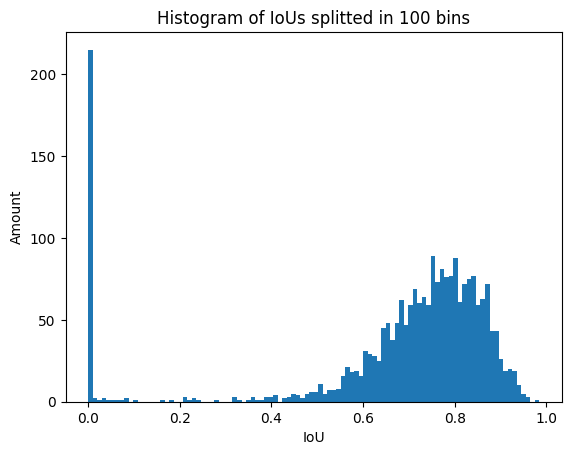

Total amount of zeros: 213
Total amount of non-zeros: 2069
Average IoU: 0.6731450598522436


In [16]:
%matplotlib inline

import torch
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

def box_iou(box1, box2):
    xi1 = max([box1[0], box2[0]])
    yi1 = max([box1[1], box2[1]])
    xi2 = min([box1[2], box2[2]])
    yi2 = min([box1[3], box2[3]])

    inter_area = max([(xi2 - xi1), 0]) * max([(yi2 - yi1), 0])
    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area

def get_boxes(file):
    boxes = dict()
    with open(file, "r") as f:
        for line in f.readlines():
            cls, xc, yc, w, h = map(float, line.strip().split())
            x1 = xc - w/2
            y1 = yc - h/2
            x2 = xc + w/2
            y2 = yc + h/2
            if cls not in boxes:
                boxes[cls] = []
            boxes[cls].append((x1, y1, x2, y2))
    return boxes

def count_iou(pred_path, gt_path):
    ious = []
    for root, dirs, files in os.walk(pred_path):
        print(f"Cur dir: {root}")
        for file in tqdm(files):
            boxes_pred = get_boxes(os.path.join(root, file))
            boxes_gt = get_boxes(os.path.join(gt_path, file))
            for cur_cls, cur_pred_boxes in boxes_pred.items():
                for pred_box in cur_pred_boxes:
                    this_box_ious = [0]
                    if cur_cls in boxes_gt:
                        for gt_box in boxes_gt[cur_cls]:
                            this_box_ious.append(box_iou(pred_box, gt_box))
                    ious.append(max(this_box_ious))
    return ious


pred_ious = count_iou("./runs/detect/predict3/labels", "./YOLOv5-SVHN-1/test/labels")
plt.hist(pred_ious, bins=100)
plt.xlabel("IoU")
plt.ylabel("Amount")
plt.title("Histogram of IoUs splitted in 100 bins")
plt.show()
print(f"Total amount of zeros: {sum([i == 0 for i in pred_ious])}")
print(f"Total amount of non-zeros: {sum([i != 0 for i in pred_ious])}")
print(f"Average IoU: {sum(pred_ious)/len(pred_ious)}")

In [17]:
results = model.predict(
    source="./myimages",
    save=True,
    save_txt=True,
    plots=True,
    conf=0.1,
    iou=0.3,
    imgsz=768,
)


image 1/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8439.jpg: 768x576 1 6, 70.5ms
image 2/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8685.jpeg: 672x768 1 6, 32.4ms
image 3/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8686.jpeg: 768x576 1 10, 1 2, 1 8, 28.7ms
image 4/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8690.jpg: 576x768 1 2, 25.0ms
image 5/5 /Users/fireguy/PycharmProjects/CVLab/lab2/myimages/IMG_8691.jpg: 768x704 1 3, 1 6, 21.9ms
Speed: 7.6ms preprocess, 35.7ms inference, 5.2ms postprocess per image at shape (1, 3, 768, 704)
Results saved to /Users/fireguy/PycharmProjects/CVLab/lab2/runs/detect/predict3
997 labels saved to /Users/fireguy/PycharmProjects/CVLab/lab2/runs/detect/predict3/labels
